# EE 451: Communications Systems
## Lesson 7 — SSB & Hilbert Transform

### Learning Objectives
By the end of this lesson, you will be able to:
- Explain the bandwidth efficiency motivation for SSB modulation
- Derive SSB signals using the Hilbert transform
- Compare USB and LSB signal generation
- Analyze Vestigial Sideband (VSB) modulation
- Calculate power and bandwidth savings for SSB vs DSB

### Textbook Reference
Haykin & Moher, Chapter 3.6–3.8

In [1]:
# Setup: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

print("Setup complete! NumPy version:", np.__version__)

Setup complete! NumPy version: 2.4.1


## Part 1: SSB Motivation — DSB Wastes Bandwidth

**DSB-SC** uses bandwidth $2B$ for a message with bandwidth $B$.
Both sidebands carry the same information — this is redundant.

**SSB** transmits only one sideband:
- **USB** (Upper Sideband): Frequencies above $f_c$
- **LSB** (Lower Sideband): Frequencies below $f_c$

**Result:** Bandwidth = $B$ instead of $2B$ (50% savings).

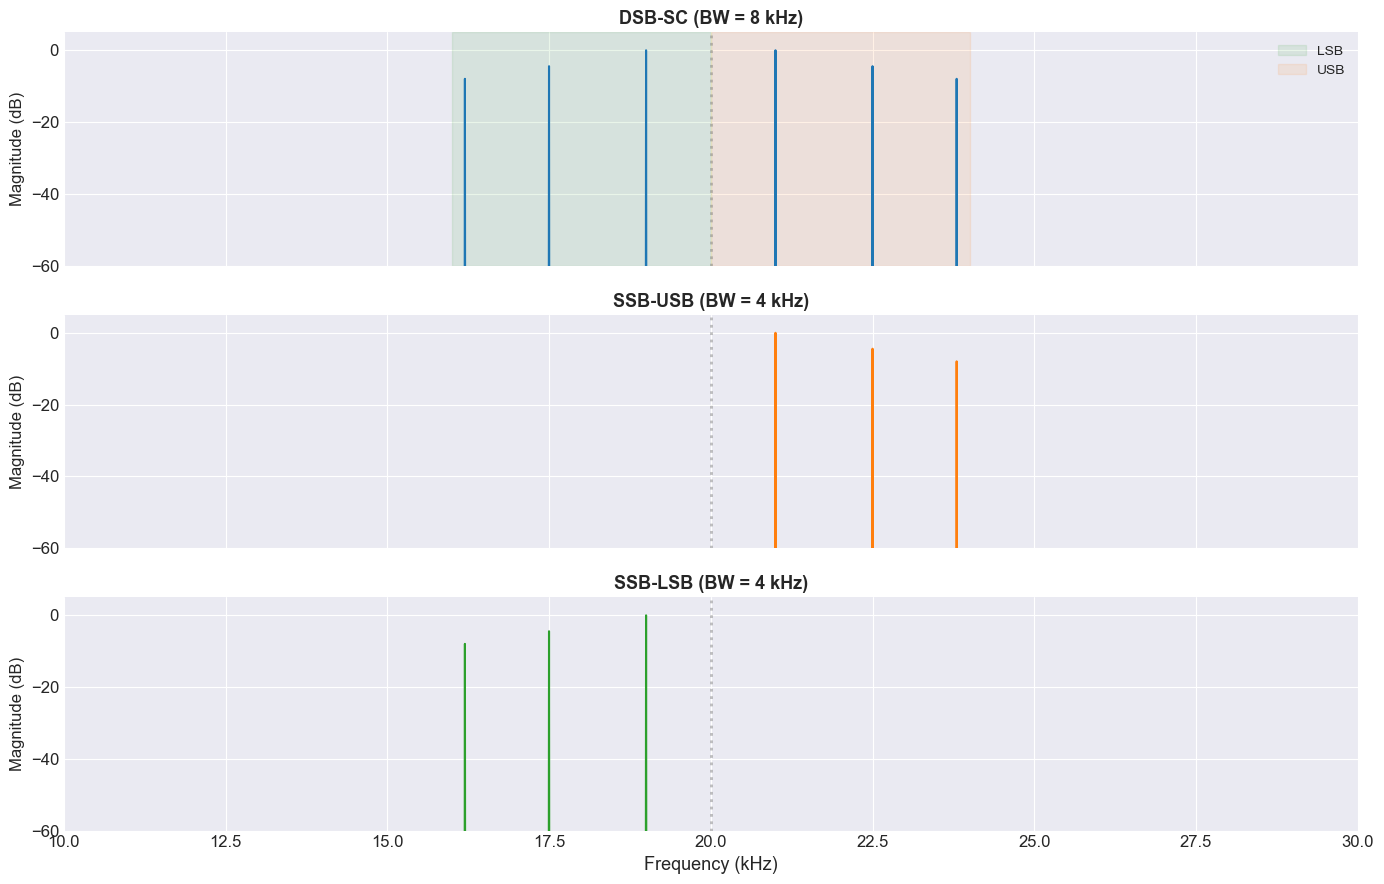

Bandwidth Comparison:
  Message bandwidth: B = 4 kHz
  DSB-SC bandwidth:  2B = 8 kHz
  SSB bandwidth:     B = 4 kHz (50% savings!)
  Carrier frequency: fc = 20 kHz


In [2]:
# === Part 1: DSB-SC vs SSB Spectrum Comparison ===

# Generate a baseband message signal
fs = 100000   # Sampling rate
T = 0.1       # Duration
t = np.arange(0, T, 1/fs)
N = len(t)
nyq = fs / 2

# Multi-tone message (bandwidth B = 4 kHz)
f1, f2, f3 = 1000, 2500, 3800
A1, A2, A3 = 0.5, 0.3, 0.2
m = A1 * np.cos(2 * np.pi * f1 * t) + A2 * np.cos(2 * np.pi * f2 * t) + A3 * np.cos(2 * np.pi * f3 * t)

fc = 20000  # Carrier frequency
B = 4000    # Message bandwidth

# DSB-SC: m(t)·cos(2πfc·t) — contains both sidebands
dsb = m * np.cos(2 * np.pi * fc * t)

# SSB by direct tone construction (exact — no filter artifacts)
# cos(2πfk·t)·cos(2πfc·t) = ½[cos(2π(fc-fk)t) + cos(2π(fc+fk)t)]
# USB keeps the fc+fk terms; LSB keeps the fc-fk terms
ssb_usb = sum(Ak/2 * np.cos(2 * np.pi * (fc + fk) * t)
              for Ak, fk in [(A1, f1), (A2, f2), (A3, f3)])
ssb_lsb = sum(Ak/2 * np.cos(2 * np.pi * (fc - fk) * t)
              for Ak, fk in [(A1, f1), (A2, f2), (A3, f3)])

# Compute spectra
freqs = fftfreq(N, 1/fs)[:N//2]
def spectrum_dB(sig):
    S = np.abs(fft(sig))[:N//2]
    return 20 * np.log10(S / np.max(S) + 1e-10)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, sig, title, color in [
    (axes[0], dsb, f'DSB-SC (BW = {2*B/1000:.0f} kHz)', 'C0'),
    (axes[1], ssb_usb, f'SSB-USB (BW = {B/1000:.0f} kHz)', 'C1'),
    (axes[2], ssb_lsb, f'SSB-LSB (BW = {B/1000:.0f} kHz)', 'C2')
]:
    ax.plot(freqs / 1000, spectrum_dB(sig), color, linewidth=1.5)
    ax.set_ylabel('Magnitude (dB)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(-60, 5)
    ax.axvline(fc / 1000, color='gray', linestyle=':', alpha=0.5)

# Shade sidebands on DSB
axes[0].axvspan((fc - B) / 1000, fc / 1000, alpha=0.1, color='C2', label='LSB')
axes[0].axvspan(fc / 1000, (fc + B) / 1000, alpha=0.1, color='C1', label='USB')
axes[0].legend(fontsize=10)

axes[2].set_xlabel('Frequency (kHz)', fontsize=13)
axes[2].set_xlim(10, 30)

plt.tight_layout()
plt.show()

print(f"Bandwidth Comparison:")
print(f"  Message bandwidth: B = {B/1000:.0f} kHz")
print(f"  DSB-SC bandwidth:  2B = {2*B/1000:.0f} kHz")
print(f"  SSB bandwidth:     B = {B/1000:.0f} kHz (50% savings!)")
print(f"  Carrier frequency: fc = {fc/1000:.0f} kHz")

## Part 2: Hilbert Transform

The **Hilbert transform** $\hat{m}(t)$ is a 90° phase shift of $m(t)$:
- Each frequency component is shifted by $-90°$
- The amplitude spectrum is unchanged
- In Python: `scipy.signal.hilbert()` returns the **analytic signal**
  $z(t) = m(t) + j\hat{m}(t)$

**SSB formulas using Hilbert transform:**
$$s_{\text{USB}}(t) = m(t)\cos(2\pi f_c t) - \hat{m}(t)\sin(2\pi f_c t)$$
$$s_{\text{LSB}}(t) = m(t)\cos(2\pi f_c t) + \hat{m}(t)\sin(2\pi f_c t)$$

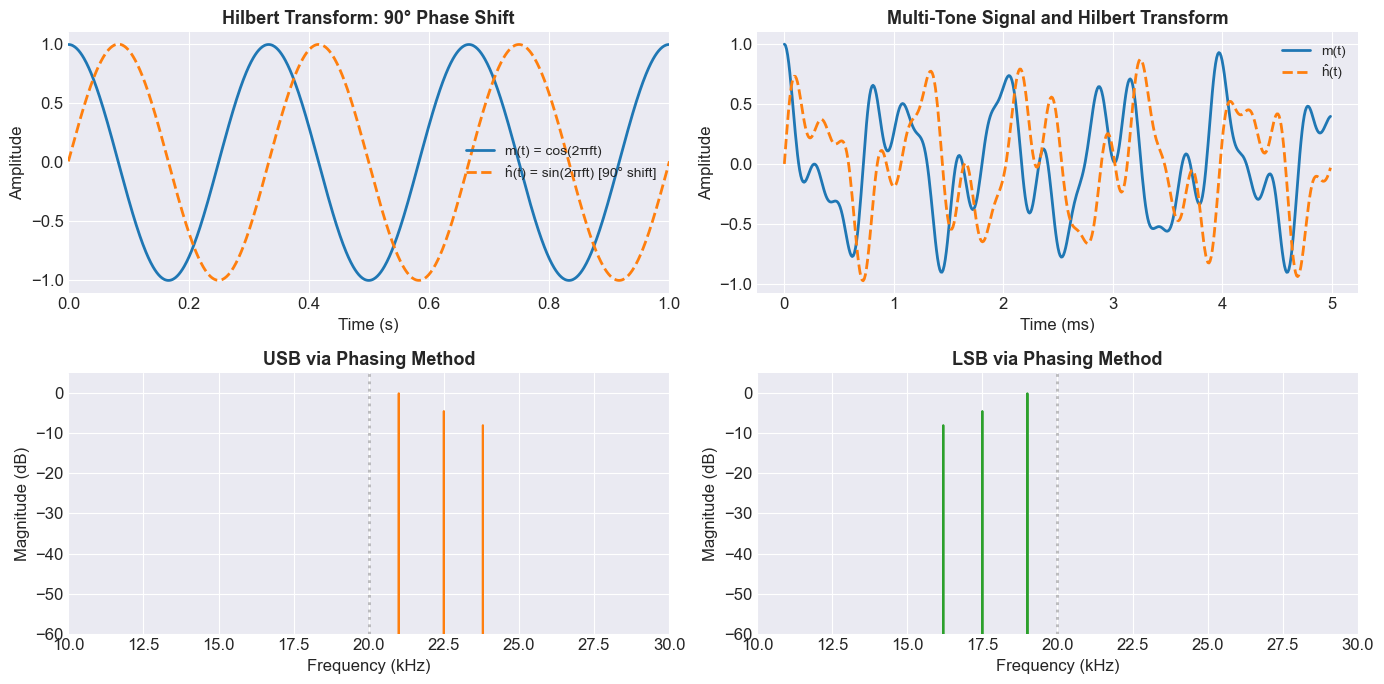

Hilbert Transform Properties:
  cos(2πft) → sin(2πft)   [90° phase shift]
  sin(2πft) → -cos(2πft)  [90° phase shift]
  Amplitude spectrum: unchanged

SSB Generation (Phasing Method):
  USB: m(t)cos(ω_c t) - ĥ(t)sin(ω_c t)
  LSB: m(t)cos(ω_c t) + ĥ(t)sin(ω_c t)


In [3]:
# === Part 2: Hilbert Transform Demonstration ===

# Simple example: cosine -> -sine via Hilbert transform
f_demo = 3.0  # Hz
t_demo = np.linspace(0, 2, 2000)
m_demo = np.cos(2 * np.pi * f_demo * t_demo)

# Hilbert transform using scipy
analytic = signal.hilbert(m_demo)
m_hat_demo = np.imag(analytic)  # Hilbert transform = imaginary part

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# Time domain
axes[0, 0].plot(t_demo, m_demo, 'C0', label='m(t) = cos(2\u03c0ft)')
axes[0, 0].plot(t_demo, m_hat_demo, 'C1--', label='\u0125(t) = sin(2\u03c0ft) [90\u00b0 shift]')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].set_title('Hilbert Transform: 90\u00b0 Phase Shift', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].set_xlim(0, 1)

# Multi-tone message
m_hat = np.imag(signal.hilbert(m))  # Hilbert transform of message

axes[0, 1].plot(t[:500] * 1000, m[:500], 'C0', label='m(t)')
axes[0, 1].plot(t[:500] * 1000, m_hat[:500], 'C1--', label='\u0125(t)')
axes[0, 1].set_xlabel('Time (ms)')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].set_title('Multi-Tone Signal and Hilbert Transform', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=10)

# Generate SSB using phasing method
ssb_usb_phasing = m * np.cos(2 * np.pi * fc * t) - m_hat * np.sin(2 * np.pi * fc * t)
ssb_lsb_phasing = m * np.cos(2 * np.pi * fc * t) + m_hat * np.sin(2 * np.pi * fc * t)

# Spectra comparison
axes[1, 0].plot(freqs / 1000, spectrum_dB(ssb_usb_phasing), 'C1', linewidth=1.5)
axes[1, 0].set_xlabel('Frequency (kHz)')
axes[1, 0].set_ylabel('Magnitude (dB)')
axes[1, 0].set_title('USB via Phasing Method', fontsize=13, fontweight='bold')
axes[1, 0].set_xlim(10, 30)
axes[1, 0].set_ylim(-60, 5)
axes[1, 0].axvline(fc / 1000, color='gray', linestyle=':', alpha=0.5)

axes[1, 1].plot(freqs / 1000, spectrum_dB(ssb_lsb_phasing), 'C2', linewidth=1.5)
axes[1, 1].set_xlabel('Frequency (kHz)')
axes[1, 1].set_ylabel('Magnitude (dB)')
axes[1, 1].set_title('LSB via Phasing Method', fontsize=13, fontweight='bold')
axes[1, 1].set_xlim(10, 30)
axes[1, 1].set_ylim(-60, 5)
axes[1, 1].axvline(fc / 1000, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("Hilbert Transform Properties:")
print(f"  cos(2\u03c0ft) \u2192 sin(2\u03c0ft)   [90\u00b0 phase shift]")
print(f"  sin(2\u03c0ft) \u2192 -cos(2\u03c0ft)  [90\u00b0 phase shift]")
print(f"  Amplitude spectrum: unchanged")
print(f"\nSSB Generation (Phasing Method):")
print(f"  USB: m(t)cos(\u03c9_c t) - \u0125(t)sin(\u03c9_c t)")
print(f"  LSB: m(t)cos(\u03c9_c t) + \u0125(t)sin(\u03c9_c t)")

## Part 3: SSB Demodulation

SSB is demodulated using **coherent detection** (same as DSB-SC):
1. Multiply by $\cos(2\pi f_c t)$
2. Lowpass filter to extract the message

**Key requirement:** The local oscillator must be frequency- and phase-locked
to the carrier (or a pilot tone is transmitted for synchronization).

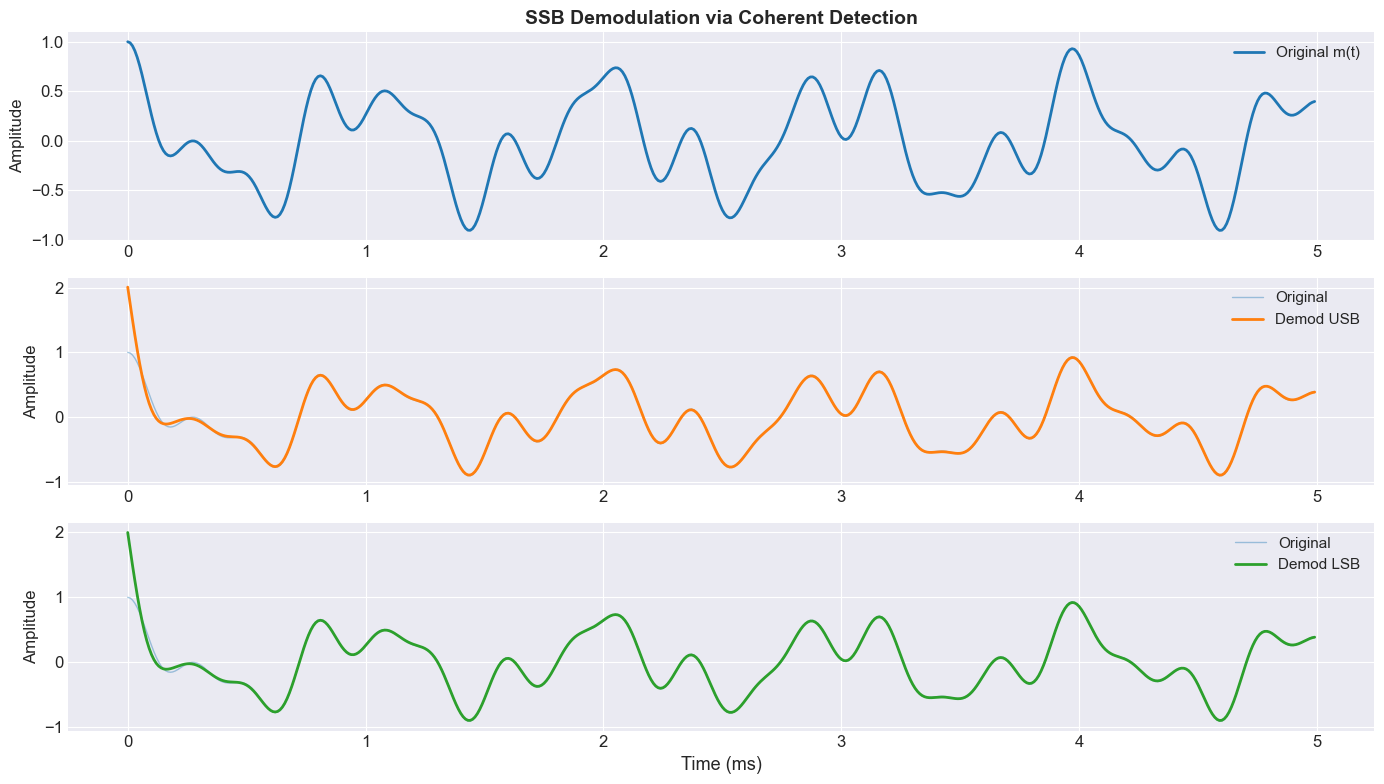

Demodulation Quality:
  USB reconstruction error (NMSE): 0.0502 (-26.0 dB)
  LSB reconstruction error (NMSE): 0.0466 (-26.6 dB)
  Both sidebands recover the original message faithfully


In [4]:
# === Part 3: SSB Demodulation ===

# Demodulate USB
demod_product = ssb_usb_phasing * 2 * np.cos(2 * np.pi * fc * t)

# Lowpass filter
b_lpf, a_lpf = signal.butter(6, B * 1.2 / nyq, btype='low')
demod_usb = signal.filtfilt(b_lpf, a_lpf, demod_product)

# Demodulate LSB
demod_product_lsb = ssb_lsb_phasing * 2 * np.cos(2 * np.pi * fc * t)
demod_lsb = signal.filtfilt(b_lpf, a_lpf, demod_product_lsb)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

show = 500  # samples to show
axes[0].plot(t[:show] * 1000, m[:show], 'C0', linewidth=2, label='Original m(t)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('SSB Demodulation via Coherent Detection', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)

axes[1].plot(t[:show] * 1000, m[:show], 'C0', linewidth=1, alpha=0.4, label='Original')
axes[1].plot(t[:show] * 1000, demod_usb[:show], 'C1', linewidth=2, label='Demod USB')
axes[1].set_ylabel('Amplitude')
axes[1].legend(fontsize=11)

axes[2].plot(t[:show] * 1000, m[:show], 'C0', linewidth=1, alpha=0.4, label='Original')
axes[2].plot(t[:show] * 1000, demod_lsb[:show], 'C2', linewidth=2, label='Demod LSB')
axes[2].set_xlabel('Time (ms)', fontsize=13)
axes[2].set_ylabel('Amplitude')
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.show()

# Measure reconstruction quality
err_usb = np.sqrt(np.mean((m - demod_usb)**2)) / np.sqrt(np.mean(m**2))
err_lsb = np.sqrt(np.mean((m - demod_lsb)**2)) / np.sqrt(np.mean(m**2))
print(f"Demodulation Quality:")
print(f"  USB reconstruction error (NMSE): {err_usb:.4f} ({20*np.log10(err_usb):.1f} dB)")
print(f"  LSB reconstruction error (NMSE): {err_lsb:.4f} ({20*np.log10(err_lsb):.1f} dB)")
print(f"  Both sidebands recover the original message faithfully")

## Part 4: VSB — Vestigial Sideband

**VSB** is a compromise between DSB and SSB:
- Transmit one full sideband + a **vestige** (remnant) of the other
- Easier to filter than SSB (gradual transition instead of sharp cutoff)
- Used in analog TV (NTSC, PAL) and some digital systems

**Bandwidth:** $B < BW_{VSB} < 2B$

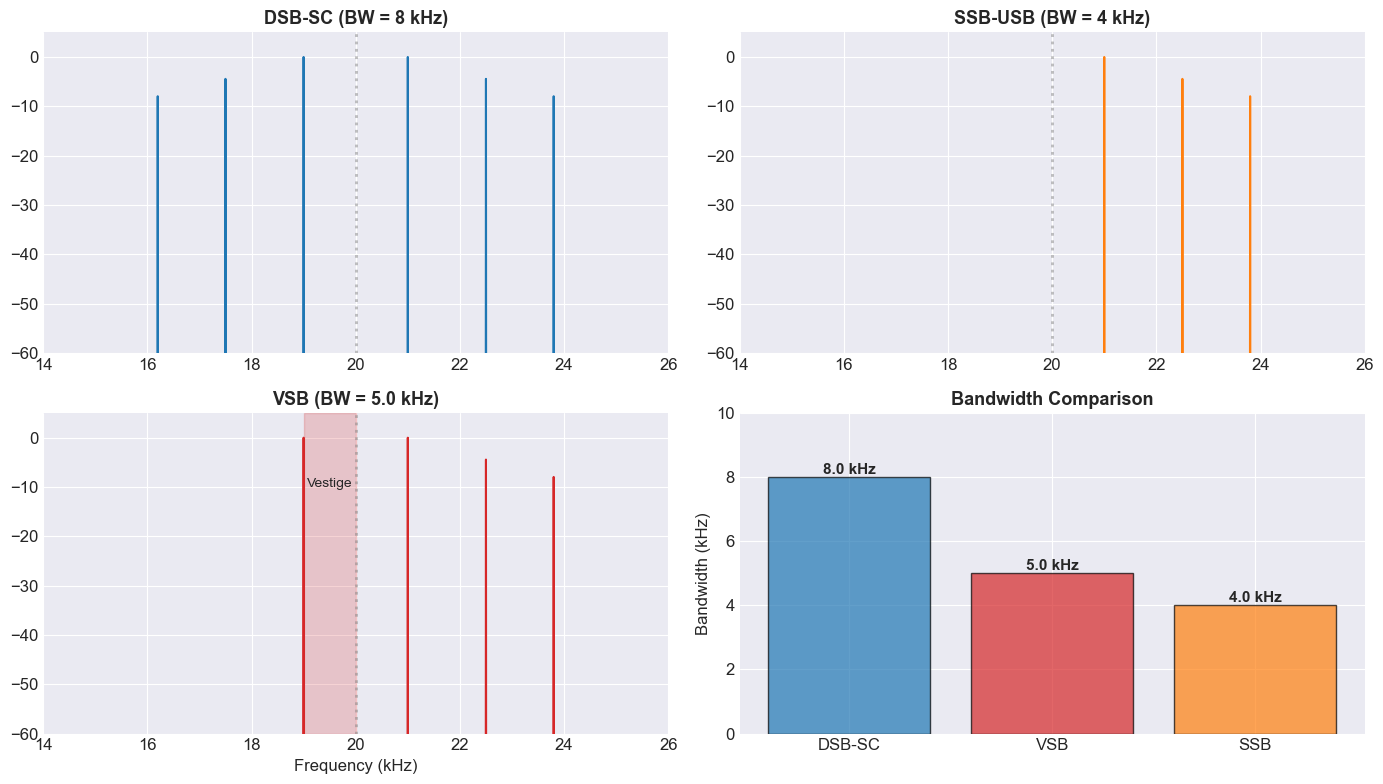

Modulation Scheme Comparison:
Scheme     Bandwidth       Filter               Application
------------------------------------------------------------
DSB-SC     2B = 8 kHz      Easy (no sharp)      Simple systems
VSB        B+Δ = 5 kHz     Moderate             Analog TV
SSB        B = 4 kHz       Hard (sharp cutoff)  Amateur radio


In [5]:
# === Part 4: VSB Modulation ===

# VSB: transmit USB + partial LSB (vestige)
vestige_bw = B * 0.25  # 25% of message bandwidth = 1 kHz

# Direct construction (no filter artifacts)
# DSB has 6 tones: fc ± f1, fc ± f2, fc ± f3  (already clean from cell 3)
# SSB-USB has 3 tones: fc + f1, fc + f2, fc + f3  (from cell 3)
# VSB = full USB + LSB tones within the vestige band (fk ≤ vestige_bw)
#   f1 = 1000 Hz ≤ 1000 Hz vestige → include fc - f1
#   f2 = 2500 Hz > 1000 Hz vestige → excluded
#   f3 = 3800 Hz > 1000 Hz vestige → excluded
tones = [(A1, f1), (A2, f2), (A3, f3)]
vsb = sum(Ak/2 * np.cos(2 * np.pi * (fc + fk) * t) for Ak, fk in tones)  # full USB
vsb = vsb + sum(Ak/2 * np.cos(2 * np.pi * (fc - fk) * t)
                for Ak, fk in tones if fk <= vestige_bw)                   # vestige of LSB

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# DSB spectrum (dsb from cell 3 — exact sum of cosines, clean)
axes[0, 0].plot(freqs / 1000, spectrum_dB(dsb), 'C0', linewidth=1.5)
axes[0, 0].set_title('DSB-SC (BW = 8 kHz)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlim(14, 26)
axes[0, 0].set_ylim(-60, 5)
axes[0, 0].axvline(fc / 1000, color='gray', linestyle=':', alpha=0.5)

# SSB-USB spectrum (ssb_usb from cell 3 — direct tone construction, clean)
axes[0, 1].plot(freqs / 1000, spectrum_dB(ssb_usb), 'C1', linewidth=1.5)
axes[0, 1].set_title('SSB-USB (BW = 4 kHz)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlim(14, 26)
axes[0, 1].set_ylim(-60, 5)
axes[0, 1].axvline(fc / 1000, color='gray', linestyle=':', alpha=0.5)

# VSB spectrum (direct construction — clean)
axes[1, 0].plot(freqs / 1000, spectrum_dB(vsb), 'C3', linewidth=1.5)
axes[1, 0].set_title(f'VSB (BW = {(B + vestige_bw)/1000:.1f} kHz)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlim(14, 26)
axes[1, 0].set_ylim(-60, 5)
axes[1, 0].axvline(fc / 1000, color='gray', linestyle=':', alpha=0.5)
axes[1, 0].axvspan((fc - vestige_bw) / 1000, fc / 1000, alpha=0.2, color='C3')
axes[1, 0].text((fc - vestige_bw/2) / 1000, -10, 'Vestige', ha='center', fontsize=10)
axes[1, 0].set_xlabel('Frequency (kHz)', fontsize=12)

# Bandwidth comparison bar chart
schemes = ['DSB-SC', 'VSB', 'SSB']
bws = [2*B/1000, (B + vestige_bw)/1000, B/1000]
colors = ['C0', 'C3', 'C1']
bars = axes[1, 1].bar(schemes, bws, color=colors, alpha=0.7, edgecolor='black')
for bar, bw_val in zip(bars, bws):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{bw_val:.1f} kHz', ha='center', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Bandwidth (kHz)', fontsize=12)
axes[1, 1].set_title('Bandwidth Comparison', fontsize=13, fontweight='bold')
axes[1, 1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

print("Modulation Scheme Comparison:")
print(f"{'Scheme':<10} {'Bandwidth':<15} {'Filter':<20} {'Application'}")
print("-" * 60)
print(f"{'DSB-SC':<10} {'2B = 8 kHz':<15} {'Easy (no sharp)':<20} {'Simple systems'}")
print(f"{'VSB':<10} {'B+\u0394 = 5 kHz':<15} {'Moderate':<20} {'Analog TV'}")
print(f"{'SSB':<10} {'B = 4 kHz':<15} {'Hard (sharp cutoff)':<20} {'Amateur radio'}")

## Summary

### Key Formulas

| Quantity | Formula |
|----------|--------|
| SSB-USB | $s(t) = m(t)\cos(\omega_c t) - \hat{m}(t)\sin(\omega_c t)$ |
| SSB-LSB | $s(t) = m(t)\cos(\omega_c t) + \hat{m}(t)\sin(\omega_c t)$ |
| DSB bandwidth | $BW_{DSB} = 2B$ |
| SSB bandwidth | $BW_{SSB} = B$ |
| Hilbert transform | 90° phase shift of all frequency components |

### Key Takeaways

1. **SSB saves 50% bandwidth** vs DSB (transmit one sideband only)
2. **Hilbert transform** ($\hat{m}(t)$) is the key to SSB generation
3. **Filter method:** DSB followed by sideband filter (requires sharp cutoff)
4. **Phasing method:** Use Hilbert transform to cancel unwanted sideband
5. **VSB** is a practical compromise (used in analog TV)
6. SSB is widely used in **amateur radio** (HF) and military communications

### Next Topics
- **Lesson 8:** Receiver Architectures & Exam 1 Review
- Superheterodyne, direct conversion, SDR